In [ ]:
import pandas_datareader.data as web
import datetime
import pandas as pd

import yfinance as yf

data = yf.download(
    "WMT",
    start="2000-01-01",
    end="2025-01-19",
    auto_adjust=True
)

data

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,WMT,WMT,WMT,WMT,WMT
Date,,,,,
2000-01-03,14.120734,14.583060,13.843339,14.450968,25109700
2000-01-04,13.592356,13.909379,13.565936,13.843331,20235300
2000-01-05,13.314966,13.605570,13.143246,13.499897,21056100
2000-01-06,13.460273,13.645201,13.248922,13.314970,19633500
2000-01-07,14.477384,14.569850,13.631990,13.631990,23930700
...,...,...,...,...,...
2025-01-13,90.088493,90.974321,89.665265,90.669205,18617100
2025-01-14,89.360146,90.531407,89.143609,90.413294,13549200


In [12]:
data.columns = data.columns.droplevel(1)

In [13]:
data = data.reset_index()

In [14]:
data

Price,Date,Close,High,Low,Open,Volume
0,2000-01-03,14.120734,14.583060,13.843339,14.450968,25109700
1,2000-01-04,13.592356,13.909379,13.565936,13.843331,20235300
2,2000-01-05,13.314966,13.605570,13.143246,13.499897,21056100
3,2000-01-06,13.460273,13.645201,13.248922,13.314970,19633500
4,2000-01-07,14.477384,14.569850,13.631990,13.631990,23930700
...,...,...,...,...,...,...
6295,2025-01-13,90.088493,90.974321,89.665265,90.669205,18617100
6296,2025-01-14,89.360146,90.531407,89.143609,90.413294,13549200
6297,2025-01-15,89.901482,90.285346,89.379830,89.635737,17348200
6298,2025-01-16,89.862106,90.275490,88.700690,90.058953,13267700


In [15]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

sdf = spark.createDataFrame(data)

In [16]:
sdf

DataFrame[Date: timestamp, Close: double, High: double, Low: double, Open: double, Volume: bigint]

In [17]:
sdf.count()

6300

In [18]:
sdf.show(5000)

+-------------------+------------------+------------------+------------------+------------------+---------+
|               Date|             Close|              High|               Low|              Open|   Volume|
+-------------------+------------------+------------------+------------------+------------------+---------+
|2000-01-03 00:00:00|14.120734214782715|14.583060302338149| 13.84333904598824|14.450968171048277| 25109700|
|2000-01-04 00:00:00|13.592355728149414|13.909378602275346|13.565936349074724|13.843331363934917| 20235300|
|2000-01-05 00:00:00|13.314966201782227|13.605569816621676|13.143246213744401|13.499897094149283| 21056100|
|2000-01-06 00:00:00|13.460272789001465|13.645201311728817| 13.24892245060703|13.314969733692068| 19633500|
|2000-01-07 00:00:00|14.477383613586426|14.569850272525809|13.631989709171362|13.631989709171362| 23930700|
|2000-01-10 00:00:00|14.213207244873047|14.266043637298036|13.869764647373092|14.213207244873047| 20142900|
|2000-01-11 00:00:00|14.0018

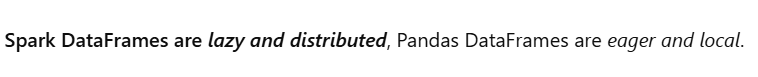

In [19]:
sdf

DataFrame[Date: timestamp, Close: double, High: double, Low: double, Open: double, Volume: bigint]

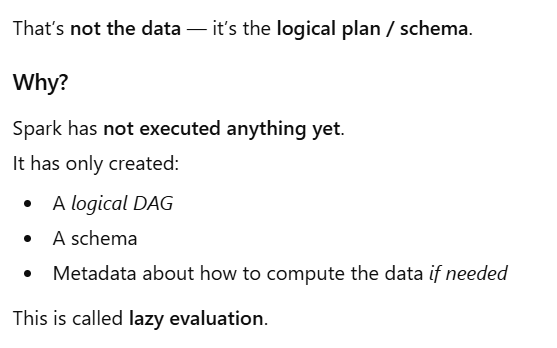

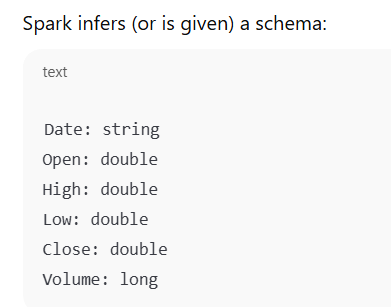

In [20]:
sdf2 = sdf.filter(sdf.Close > 40)

In [21]:
sdf2

DataFrame[Date: timestamp, Close: double, High: double, Low: double, Open: double, Volume: bigint]

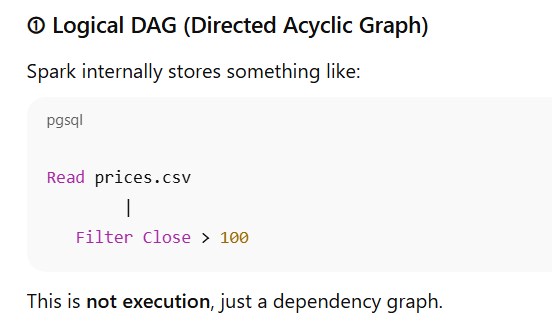

In [24]:
sdf3 = sdf2.withColumn("day_diff", sdf2.Close -sdf2.Open)

In [23]:
sdf3

DataFrame[Date: timestamp, Close: double, High: double, Low: double, Open: double, Volume: bigint, day_diff: double]

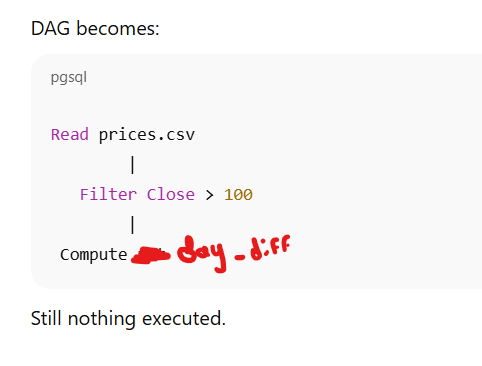

In [25]:
sdf3.show()

+-------------------+------------------+------------------+------------------+------------------+--------+--------------------+
|               Date|             Close|              High|               Low|              Open|  Volume|            day_diff|
+-------------------+------------------+------------------+------------------+------------------+--------+--------------------+
|2020-04-16 00:00:00| 40.45719909667969| 40.63757960986667|  39.2098217513326| 39.43911895455676|31882200|  1.0180801421229262|
|2020-04-17 00:00:00| 40.39299011230469| 40.65285977054639| 39.66229432149614| 40.19732338144989|30915300| 0.19566673085479636|
|2020-04-22 00:00:00|40.230953216552734| 40.47247867780744|39.408539970030354|   39.744840846598|19448100| 0.48611236995473206|
|2020-07-10 00:00:00| 40.12849426269531|40.340375231934956| 39.07829659045441|  39.5327690225264|44236800|  0.5957252401689104|
|2020-07-14 00:00:00| 40.53690719604492| 40.68737422312228| 39.62182294329803|39.698593914490125|2645580

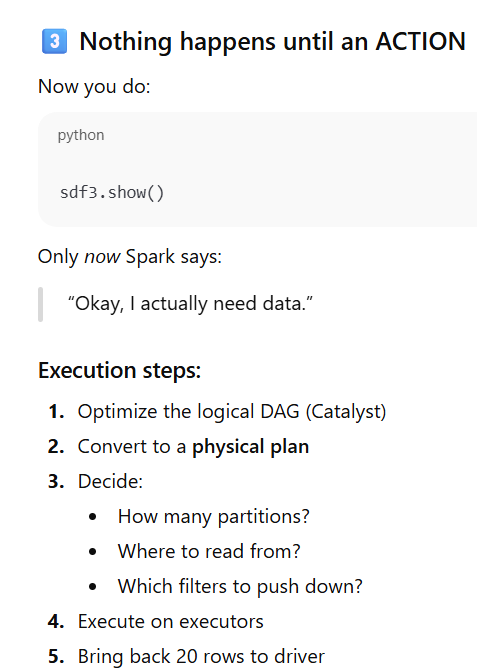

In [ ]:
sdf.columns

['Open', 'High', 'Low', 'Close', 'Volume']

In [ ]:
sdf.printSchema()

root
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: double (nullable = true)



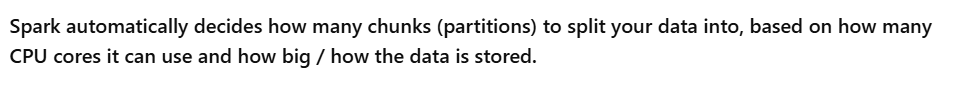

In [26]:
sdf.rdd.getNumPartitions()

2

In [ ]:
spark.sparkContext.defaultParallelism

2

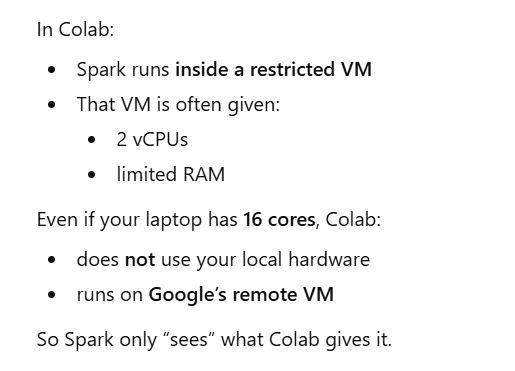

In [ ]:
sdf = sdf.repartition(8)

In [ ]:
sdf.rdd.getNumPartitions()

8

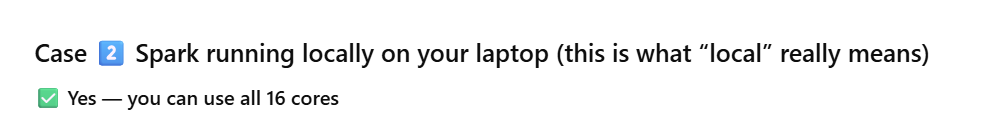

In [ ]:
sdf

DataFrame[Open: double, High: double, Low: double, Close: double, Volume: bigint, Dividends: double, Stock Splits: double]

In [27]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

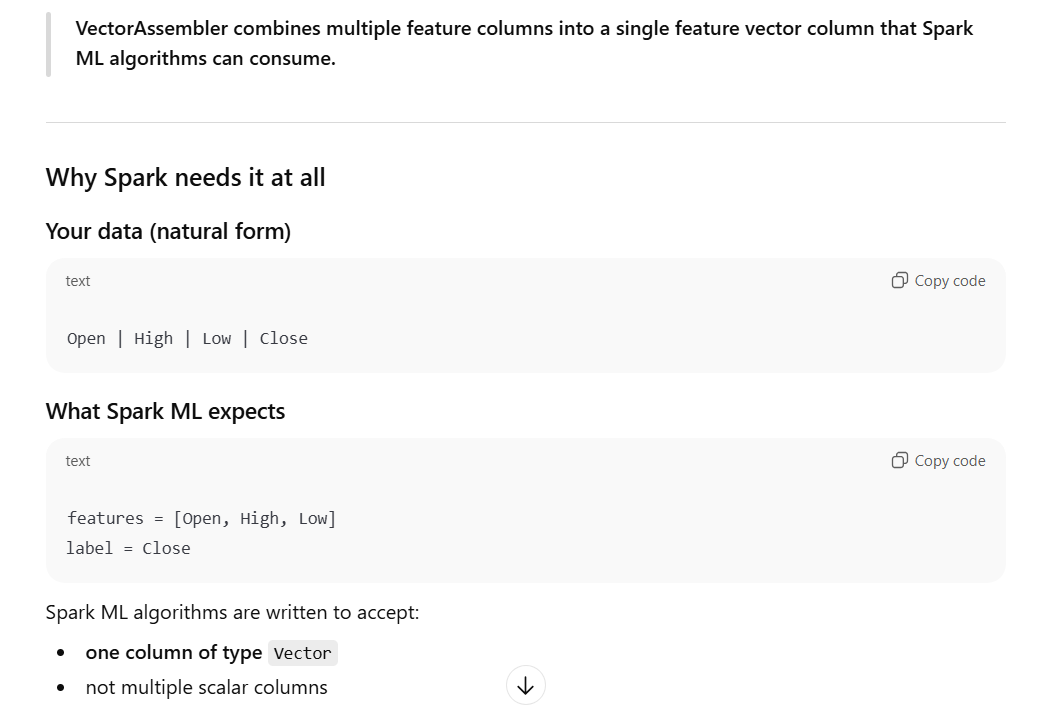

In [28]:
train_df, test_df = sdf.randomSplit([0.8, 0.2], seed=2)

In [29]:
assembler = VectorAssembler(
    inputCols=["Open", "High", "Low"],
    outputCol="features"
)

In [30]:
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="Close",
    numTrees=100,
    maxDepth=5
)

In [31]:
pipeline = Pipeline(stages=[assembler, rf])

In [32]:
model = pipeline.fit(train_df)

In [33]:
predictions = model.transform(test_df)

In [ ]:
predictions

DataFrame[Open: double, High: double, Low: double, Close: double, Volume: double, features: vector, prediction: double]

In [34]:
evaluator = RegressionEvaluator(
    labelCol="Close",
    predictionCol="prediction",
    metricName="rmse"
)

rmse = evaluator.evaluate(predictions)
print("RMSE:", rmse)

RMSE: 2.0537178947762023


In [35]:
import pandas as pd
import numpy as np
import pyspark.pandas as ps
from pyspark.sql import SparkSession

/usr/local/lib/python3.13/dist-packages/pyspark/pandas/__init__.py:43: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


In [36]:
spark.conf.set("spark.sql.ansi.enabled", "false")

In [37]:
df = ps.DataFrame(sdf)

In [38]:
len(df)

6300

In [39]:
df #df.show() equivalent

,Date,Close,High,Low,Open,Volume
0,2000-01-03,14.120734,14.583060,13.843339,14.450968,25109700
1,2000-01-04,13.592356,13.909379,13.565936,13.843331,20235300
2,2000-01-05,13.314966,13.605570,13.143246,13.499897,21056100
3,2000-01-06,13.460273,13.645201,13.248922,13.314970,19633500
4,2000-01-07,14.477384,14.569850,13.631990,13.631990,23930700
5,2000-01-10,14.213207,14.266044,13.869765,14.213207,20142900
6,2000-01-11,14.001845,14.318868,13.869753,14.173568,14829900
7,2000-01-12,13.750876,14.107527,13.750876,13.988644,12255000
8,2000-01-13,13.764085,13.975435,13.737668,13.949016,15063000
9,2000-01-14,13.631987,13.935801,13.526311,13.526311,18936600


In [40]:
df[df['Close']>50]

,Date,Close,High,Low,Open,Volume
5610,2022-04-20,50.379410,50.606644,49.956504,49.975441,19821600
5611,2022-04-21,50.455154,50.739195,50.202674,50.470934,18168300
5899,2023-06-14,50.489227,50.637279,50.083689,50.180248,21103200
5900,2023-06-15,50.766022,50.926946,50.524631,50.531066,18160500
5901,2023-06-16,50.057941,50.901198,49.977476,50.878667,34675800
5904,2023-06-22,50.128757,50.234970,49.720000,49.880929,13307400
5905,2023-06-23,50.035416,50.302556,49.893799,50.170594,18975000
5910,2023-06-30,50.589008,50.701656,49.816560,49.877710,19073100
5911,2023-07-03,50.917286,50.994529,50.315419,50.469909,8647500
5912,2023-07-05,50.888321,51.213393,50.640492,50.904413,17585400


In [41]:
df.groupby('Close').mean()

/usr/local/lib/python3.13/dist-packages/pyspark/pandas/groupby.py:3501: FutureWarning: Dropping invalid columns in DataFrameGroupBy.median is deprecated. In a future version, a TypeError will be raised. Before calling .median, select only columns which should be valid for the function.
  warnings.warn(


,High,Low,Open,Volume
Close,,,,
10.167165,10.506920,10.056745,10.056745,30106800.0
11.292122,11.366552,11.064577,11.121995,22772100.0
12.039611,12.039611,11.914871,11.914871,19563900.0
12.098097,12.162724,11.955919,12.104560,18539700.0
12.505575,12.589723,12.475368,12.574619,25839900.0
13.020324,13.143524,13.011679,13.141363,29591400.0
11.748884,11.751061,11.592173,11.624822,23418000.0
11.437130,11.509129,11.400040,11.476402,28233300.0
10.829186,10.940850,10.806853,10.815786,30279000.0
